## Xarxa amb múltiples capes (Forward Pass complet)

Una xarxa neuronal és senzillament **diverses capes denses encadenades**.
La sortida d'una capa és l'entrada de la següent.

Per exemple, amb una capa oculta i una capa de sortida:

$$A^{[1]} = \sigma(X \cdot W^{[1]} + b^{[1]})$$

$$A^{[2]} = \sigma(A^{[1]} \cdot W^{[2]} + b^{[2]})$$

On:
- $A^{[1]}$ és la sortida de la capa oculta (les seves "activacions")
- $A^{[2]}$ és la sortida final de la xarxa (la predicció)
- Cada capa té la seva pròpia matriu de pesos $W$ i el seu propi biaix $b$

Aquest procés d'anar passant les dades cap endavant, capa rere capa,
s'anomena **forward propagation**.

In [6]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def capa_densa(X, W, b):
    Z = np.dot(X, W) + b
    return sigmoid(Z)

def forward_pass(X, W1, b1, W2, b2):
    A1 = capa_densa(X, W1, b1)   # capa oculta
    A2 = capa_densa(A1, W2, b2)  # capa de sortida
    return A1, A2

# Arquitectura: 3 entrades -> 4 neurones ocultes -> 2 sortides
X  = np.array([0.5, 0.3, 0.8])

W1 = np.random.randn(3, 4)   # pesos capa oculta
b1 = np.random.randn(4)

W2 = np.random.randn(4, 2)   # pesos capa de sortida
b2 = np.random.randn(2)

A1, A2 = forward_pass(X, W1, b1, W2, b2)

print(f"Activacions capa oculta: {A1}")
print(f"Sortida final de la xarxa: {A2}")
print(f"Predicció: classe {np.argmax(A2)}")

Activacions capa oculta: [0.67800479 0.48977956 0.86972016 0.66650662]
Sortida final de la xarxa: [0.90437697 0.03285489]
Predicció: classe 0


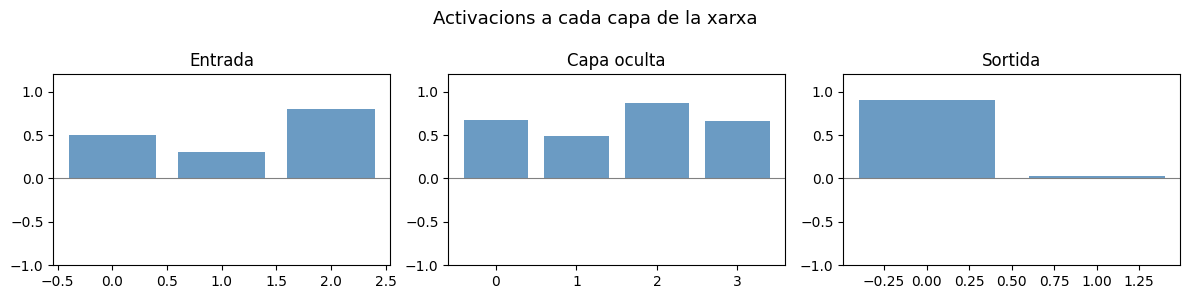

In [7]:
# Visualització de l'arquitectura i les activacions
import matplotlib.pyplot as plt

capes = [X, A1, A2]
noms = ['Entrada', 'Capa oculta', 'Sortida']

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, capa, nom in zip(axes, capes, noms):
    ax.bar(range(len(capa)), capa, color='steelblue', alpha=0.8)
    ax.set_title(nom)
    ax.set_ylim(-1, 1.2)
    ax.axhline(0, color='gray', linewidth=0.8)

plt.suptitle('Activacions a cada capa de la xarxa', fontsize=13)
plt.tight_layout()
plt.show()